# HGND sensitivity — smoke test (laptop, memory-safe)

Trains a small `net_default` on a **subset** of `defaultSpot` and evaluates
the same checkpoint on all three symmetry-potential datasets when their
preprocessed shards are on disk.

**Memory envelope on this MacBook (18 GB unified RAM):**
- Preprocessing of `zeroSpot` / `bigSpot` is NOT run here — `load_hits`
  materialises the full CSV set into pandas before `max_events` applies,
  which OOMs on 12 GB CSV dumps. Those steps run on the cluster via
  `slurm/sensitivity_smoke.sbatch` (or the fuller `sensitivity_full.sbatch`).
- Locally we cap batch = 32, hidden = 256, layers = 4, 2 shards
  (2 048 graphs), 3 epochs. Peak RSS should stay under ~3 GB.
- Datasets without a `processed/` cache are cleanly skipped with a message
  telling you which SLURM job to run to fill them in.

The pipeline is *identical* to the SLURM path (both use
`HGNDRecoGNN.scripts.train` / `.evaluate` / `.sensitivity`), so if this
runs green here, the cluster reproduction is the same code plus scale.


In [1]:
import os, sys, time, json as _json, resource, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import torch, torch_geometric

# Put the package on sys.path so `import HGNDRecoGNN` works from any cwd.
PACKAGE_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PACKAGE_ROOT not in sys.path:
    sys.path.insert(0, PACKAGE_ROOT)

from HGNDRecoGNN.data.graph_dataset import HGNDGraphDataset, SCHEMA_V
from HGNDRecoGNN import device as device_mod
from HGNDRecoGNN.models import build_default_net
from HGNDRecoGNN.training import TrainConfig, fit, predict, LossWeights
from HGNDRecoGNN.training.train import build_loaders
from HGNDRecoGNN.training.eval import save_predictions
from HGNDRecoGNN.analysis.sensitivity import (
    DatasetRun, compare_datasets, default_ekin_bins, DATASET_TO_POTENTIAL_MEV,
)

def rss_gb():
    # macOS `ru_maxrss` is bytes; Linux is kB. Detect and unify.
    r = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    return r / 1024 ** 3 if r > 10 ** 7 else r / 1024 ** 2

print(f'PyTorch {torch.__version__}   PyG {torch_geometric.__version__}')
print(f'Schema v{SCHEMA_V}   startup RSS {rss_gb():.2f} GB')


PyTorch 2.7.1   PyG 2.7.0
Schema v2   startup RSS 0.49 GB


## 1. Config — laptop-safe subset

Every knob here is deliberately smaller than the SLURM equivalent.

In [2]:
DATASETS = ['defaultSpot', 'zeroSpot', 'bigSpot']   # order = plotting order
TRAIN_DATASET = 'defaultSpot'                       # only defaultSpot has shards locally

# ── Device ───────────────────────────────────────────────────────────────
_DEV = device_mod.detect()
_DEF = device_mod.safe_defaults(_DEV)
print(f'device={_DEV}   avail_mem={device_mod.available_memory_gb(_DEV):.1f} GB')
print(f'safe_defaults: batch={_DEF.batch_size}  hidden={_DEF.hidden_channels}  layers={_DEF.num_layers}')

# ── Smoke overrides (tighter than safe_defaults) ─────────────────────────
BATCH_SIZE       = 32               # smaller than safe_defaults for MPS headroom
HIDDEN_CHANNELS  = _DEF.hidden_channels
NUM_LAYERS       = _DEF.num_layers
EPOCHS           = 6
SEED             = 42
NUM_SHARDS       = 2                # ~2048 graphs
THRESHOLD        = 0.35             # smoke threshold — 0.5 is too strict for an undertrained model
PRELOAD_MAX_GB   = 1.0              # hard ceiling on preloaded shard tensors

# ── Paths ────────────────────────────────────────────────────────────────
def dataset_root(name: str) -> str:
    # Prefer the small `_smoke` cache when present so this notebook stays
    # cheap even when full shards exist alongside.
    smoke = os.path.join(os.getcwd(), 'cache', f'ndet_dataset_smash_{name}_smoke')
    full  = os.path.join(os.getcwd(), 'cache', f'ndet_dataset_smash_{name}')
    return smoke if os.path.isdir(os.path.join(smoke, 'processed')) else full

def csv_dir(name: str) -> str:
    smoke = os.path.join(PROJECT_ROOT, 'data',
                         f'smash_xecs_2.87gev_hardSkyrme_{name}_smoke')
    full  = os.path.join(PROJECT_ROOT, 'data',
                         f'smash_xecs_2.87gev_hardSkyrme_{name}')
    return smoke if os.path.isdir(smoke) else full

CKPT_DIR  = os.path.join(os.getcwd(), 'checkpoints', 'sensitivity_smoke')
RESULTS_DIR = os.path.join(os.getcwd(), 'results', 'sensitivity_smoke')
os.makedirs(CKPT_DIR,   exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'ckpt_dir: {CKPT_DIR}')
print(f'results : {RESULTS_DIR}')


device=mps   avail_mem=5.6 GB
safe_defaults: batch=128  hidden=256  layers=4
ckpt_dir: /Users/vovvy/Project/BM@N/HGND/HGNDRecoGNN/notebooks/checkpoints/sensitivity_smoke
results : /Users/vovvy/Project/BM@N/HGND/HGNDRecoGNN/notebooks/results/sensitivity_smoke


## 2. Discover which datasets are usable locally

Preprocessing `zeroSpot` / `bigSpot` from CSV needs > 12 GB pandas peak,
so on this laptop we can only touch datasets that already have `processed/`
shards. Everything else is deferred to the cluster.

In [3]:
def dataset_status(name: str) -> dict:
    root = dataset_root(name)
    proc = os.path.join(root, 'processed')
    meta = os.path.join(proc, 'meta.json')
    flavor = 'smoke' if root.endswith('_smoke') else 'full'
    if os.path.exists(meta):
        with open(meta) as f:
            m = _json.load(f)
        return {'name': name, 'ready': True, 'flavor': flavor,
                'shards': m.get('num_shards', 0),
                'graphs': m.get('num_graphs', 0), 'schema_v': m.get('schema_version', 1),
                'root': root, 'note': ''}
    # No preprocessed cache — check if CSVs at least exist.
    has_csv = os.path.isdir(csv_dir(name))
    note = ('CSVs present — preprocess on the cluster via '
            'slurm/sensitivity_smoke.sbatch (or _full).' if has_csv
            else 'CSVs missing.')
    return {'name': name, 'ready': False, 'root': root, 'note': note}

statuses = [dataset_status(n) for n in DATASETS]
for s in statuses:
    if s['ready']:
        print(f"  ✓ {s['name']:12s}  [{s['flavor']:5s}]  {s['graphs']:>6,} graphs  "
              f"{s['shards']:>3d} shards  schema v{s['schema_v']}")
    else:
        print(f"  ✗ {s['name']:12s}  SKIP  ({s['note']})")

if not any(s['name'] == TRAIN_DATASET and s['ready'] for s in statuses):
    raise RuntimeError(
        f'training dataset {TRAIN_DATASET!r} has no preprocessed shards at '
        f'{dataset_root(TRAIN_DATASET)}. Run preprocessing first.')


  ✓ defaultSpot   [full ]  200,000 graphs  196 shards  schema v1
  ✓ zeroSpot      [smoke]   4,000 graphs    4 shards  schema v2
  ✓ bigSpot       [smoke]   4,000 graphs    4 shards  schema v2


## 3. Load a small subset of the training dataset

In [4]:
t0 = time.time()
train_ds = HGNDGraphDataset(
    root=dataset_root(TRAIN_DATASET),
    hits_csv_dir=csv_dir(TRAIN_DATASET),     # unused when shards exist
    rlocal=3.6, twindow=1.5, num_workers=0, shard_size=1024,
    num_shards=NUM_SHARDS, allow_stale_schema=True,
)
train_ds.preload(max_gb=PRELOAD_MAX_GB, verbose=True)
print(f'  {len(train_ds)} graphs   RSS {rss_gb():.2f} GB   ({time.time()-t0:.1f}s)')


[HGNDGraphDataset] WARNING: loading shards with schema v1 while code expects v2. Downstream code may crash or produce wrong results.
Preloading 2 shards into memory … 

2048 graphs loaded in 0.6s (~1 MB tensor data)
  2048 graphs   RSS 0.54 GB   (0.6s)


## 4. Build the model + train

In [5]:
cfg = TrainConfig(
    batch_size=BATCH_SIZE, seed=SEED, train_frac=0.5, epochs=EPOCHS,
    lr=1e-3, weight_decay=1e-5,
    device='auto', num_workers_loader=0,
    arch_name='net_default',
    arch_kwargs={'hidden_channels': HIDDEN_CHANNELS, 'num_layers': NUM_LAYERS},
    checkpoint_dir=CKPT_DIR,
    checkpoint_name=f'{TRAIN_DATASET}_net_default_smoke.pt',
    loss_weights=LossWeights(), verbose=True,
)
train_loader, test_loader = build_loaders(train_ds, cfg)
print(f'train {len(train_loader.dataset)}   test {len(test_loader.dataset)}')

model = build_default_net(train_ds,
                          hidden_channels=HIDDEN_CHANNELS,
                          num_layers=NUM_LAYERS)
plan = device_mod.plan_for(model, cfg.device, cfg.cpu_pinned)
device_mod.to_device(model, plan)
print(device_mod.summarize(plan))
print(f'params: {sum(p.numel() for p in model.parameters()):,}   RSS {rss_gb():.2f} GB')


train 1024   test 1024


device=mps  cpu_pinned=[cluster_conv_cpu]
params: 2,719,045   RSS 0.56 GB


fit(): device=mps  cpu_pinned=[cluster_conv_cpu]  epochs=6  batch=32  lr=0.001


train:   0%|          | 0/32 [00:00<?, ?it/s]

train:   3%|▎         | 1/32 [00:00<00:16,  1.87it/s]

train:   6%|▋         | 2/32 [00:00<00:11,  2.66it/s]

train:   9%|▉         | 3/32 [00:00<00:08,  3.49it/s]

...

eval:  66%|██████▌   | 21/32 [00:00<00:00, 32.13it/s]

eval:  78%|███████▊  | 25/32 [00:00<00:00, 33.36it/s]

eval:  91%|█████████ | 29/32 [00:00<00:00, 34.25it/s]

eval: 100%|██████████| 32/32 [00:01<00:00, 31.40it/s]

epoch 005  train 3.9037  val 3.2054  lr 1.00e-03  [best]
best epoch 5 loss 3.9037   ckpt: /Users/vovvy/Project/BM@N/HGND/HGNDRecoGNN/notebooks/checkpoints/sensitivity_smoke/defaultSpot_net_default_smoke.pt   RSS 2.33 GB


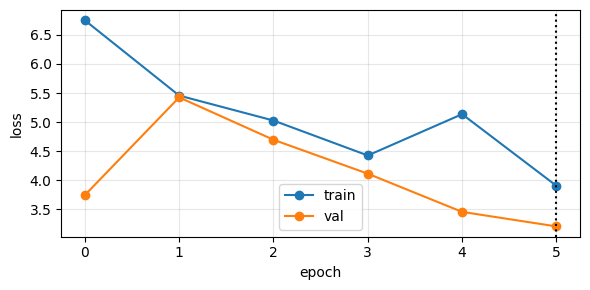

In [6]:
result = fit(model, train_loader, test_loader, cfg, plan=plan)
device_mod.empty_cache(plan.main)
print(f'best epoch {result["best_epoch"]} loss {result["best_loss"]:.4f}   '
      f'ckpt: {result["checkpoint_path"]}   RSS {rss_gb():.2f} GB')

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(result['train_loss'], marker='o', label='train')
ax.plot(result['val_loss'],   marker='o', label='val')
ax.axvline(result['best_epoch'], ls=':', c='k')
ax.set_xlabel('epoch'); ax.set_ylabel('loss'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 5. Evaluate the checkpoint on each ready dataset

For the training dataset we use the held-out test split. For any other
dataset that's ready locally we use `split='all'` — the model never saw it.
Unready datasets get an explicit skip so the sensitivity study clearly
shows how many curves are missing.

In [7]:
def eval_on(name: str, ready: bool) -> pd.DataFrame | None:
    """Evaluate the trained model on the held-out test split of `name`.

    Every dataset uses split='test' with the same seed / train_frac so
    each contributes the same number of events (~1024 on the smoke
    config) — a prerequisite for comparing raw N_reco / N_true_solved
    counts across datasets. For the training dataset this is the honest
    OOD test; for the others the "test" split is just an arbitrary
    deterministic half and produces matched sample sizes.
    """
    if not ready:
        print(f'  {name:12s}  skipped — no local shards. '
              f'Run slurm/sensitivity_smoke.sbatch on the cluster.')
        return None
    root = dataset_root(name)
    ds = HGNDGraphDataset(
        root=root, hits_csv_dir=csv_dir(name),
        rlocal=3.6, twindow=1.5, num_workers=0, shard_size=1024,
        num_shards=NUM_SHARDS, allow_stale_schema=True,
    )
    ds.preload(max_gb=PRELOAD_MAX_GB, verbose=False)

    eval_cfg = TrainConfig(batch_size=BATCH_SIZE, seed=SEED,
                           train_frac=0.5, num_workers_loader=0)
    _, loader = build_loaders(ds, eval_cfg)

    t0 = time.time()
    preds = predict(model, loader, plan=plan, verbose=False)
    elapsed = time.time() - t0
    out_dir = os.path.join(RESULTS_DIR, f'{name}_net_default')
    save_predictions(preds, out_dir, suffix='smoke')
    device_mod.empty_cache(plan.main)
    del ds, loader
    n_events = int(preds['clusters']['Row'].nunique())
    print(f'  {name:12s}  events={n_events:>4,}  '
          f'clusters={len(preds["clusters"]):>6,}  '
          f'{elapsed:>4.1f}s  RSS {rss_gb():.2f} GB')
    return preds['clusters']

cluster_dfs: dict[str, pd.DataFrame] = {}
for s in statuses:
    df = eval_on(s['name'], s['ready'])
    if df is not None:
        cluster_dfs[s['name']] = df
print(f'\nevaluated {len(cluster_dfs)} / {len(statuses)} datasets')


[HGNDGraphDataset] WARNING: loading shards with schema v1 while code expects v2. Downstream code may crash or produce wrong results.


  defaultSpot   events=1,024  clusters= 2,313   2.5s  RSS 2.33 GB


  zeroSpot      events=1,000  clusters= 2,550   6.2s  RSS 2.33 GB


  bigSpot       events=1,000  clusters= 2,621   5.6s  RSS 2.33 GB

evaluated 3 / 3 datasets


## 5b. Dataset check plots

Per-dataset ground-truth checks *before* looking at anything reconstructed.
Templates copied from `NeutronRecoGNN/notebooks/results_smash.ipynb`.

For each dataset we load its raw-hits parquet cache (small on the smoke
subsets; sliced by `Row` on the full `defaultSpot`) and plot:

- **MC-truth neutron spectrum** — one entry per unique `(Row, Id)` neutron
  track with `n0_label == 1`. This is what an ideal detector reports and
  should match the reference notebook for `defaultSpot`.
- **Neutron multiplicity** — `Nn` (all signal neutrons per event) from
  raw hits.
- **eToF signal vs background** — hit-level eToF distribution split by
  `n0_label`.

Only signal-cluster-Row subsets are loaded for `defaultSpot` to stay under
the ~3 GB memory ceiling.

In [8]:
# Locate the parquet cache written during preprocessing.
import glob

_PARQUET_COLS = ['Row', 'Instance', 'Id', 'fMotherId', 'PDG', 'Ekin',
                 'n0_label', 'eToF']

def parquet_path(name: str) -> str | None:
    root = dataset_root(name)
    hits = glob.glob(os.path.join(root, 'processed', '_hits_cache_*.parquet'))
    return hits[0] if hits else None

def load_check_frame(name: str, row_filter: set[int] | None = None) -> pd.DataFrame:
    """Load the raw-hits DataFrame slice needed for the check plots.

    We always pass `row_filter` = cluster_dfs[name]['Row'].unique() from
    the caller so the check frame contains **exactly** the events the
    model was evaluated on. That way the MC-truth spectrum plotted here
    equals the MC-truth reference drawn on top of the sensitivity plot,
    and both are conditional on the identical event subset.

    Column filtering + pandas `isin` keeps the working set tiny even on
    the full 4.4 GB defaultSpot parquet.
    """
    p = parquet_path(name)
    if p is None:
        return pd.DataFrame(columns=_PARQUET_COLS)
    df = pd.read_parquet(p, columns=_PARQUET_COLS)
    if row_filter is not None:
        df = df[df['Row'].isin(row_filter)].copy()
    # Nn = distinct signal neutron count per event
    df['Nn'] = df[(df['n0_label'] == 1) & (df['Ekin'] > 0)].groupby('Row')['Id'].transform('nunique')
    df['Nn'] = df.groupby('Row')['Nn'].transform('max').fillna(0).astype(int)
    return df

# Build one check DataFrame per dataset, restricted to the test-split
# Rows actually seen by predict() — so multiplicity / eToF / MC-truth
# distributions here are on the same events as the sensitivity numbers.
check_frames: dict[str, pd.DataFrame] = {}
for name, df in cluster_dfs.items():
    row_set = set(df['Row'].unique())
    t0 = time.time()
    frame = load_check_frame(name, row_filter=row_set)
    check_frames[name] = frame
    mem_mb = frame.memory_usage(deep=True).sum() / 1e6
    print(f'  {name:12s}  hits={len(frame):>6,}  events={frame.Row.nunique():>4,}  '
          f'signal_hits={int((frame.n0_label==1).sum()):>5,}  '
          f'{mem_mb:>5.1f} MB  ({time.time()-t0:.1f}s)')
print(f'RSS after loading check frames: {rss_gb():.2f} GB')


  defaultSpot   hits=14,699  events=1,024  signal_hits=2,012    1.2 MB  (1.1s)
  zeroSpot      hits=15,353  events=1,000  signal_hits=2,084    1.2 MB  (0.0s)
  bigSpot       hits=15,787  events=1,000  signal_hits=2,382    1.3 MB  (0.0s)
RSS after loading check frames: 2.33 GB


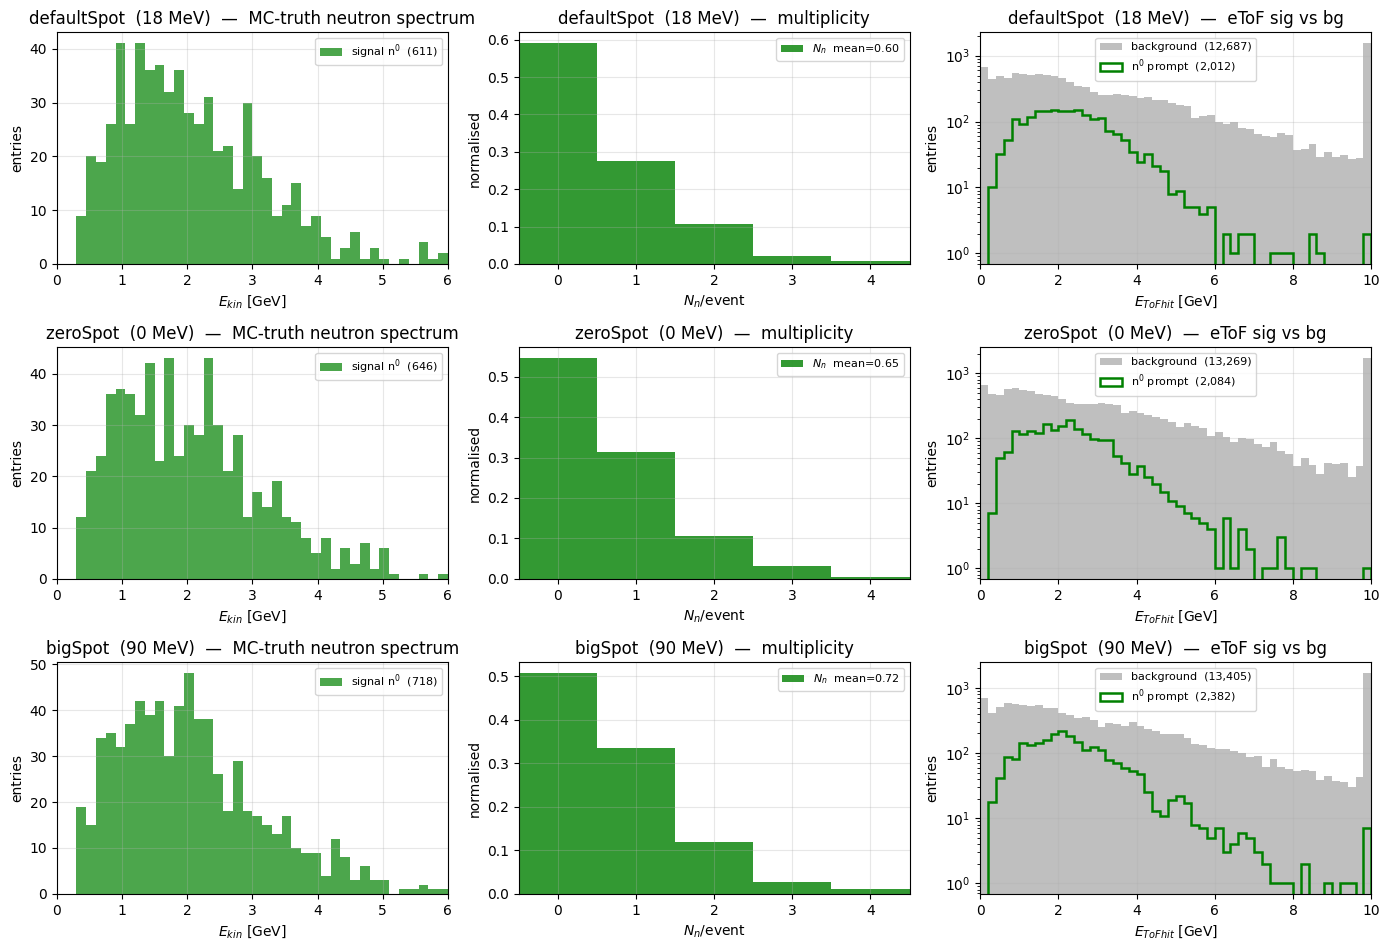

In [9]:
# 3×3 grid: rows=datasets, cols=(MC-truth spectrum, multiplicity, eToF).
n = len(check_frames)
fig, axes = plt.subplots(n, 3, figsize=(14, 3.2 * n))
if n == 1:
    axes = axes.reshape(1, -1)

E_RANGE  = (0, 6)     # GeV — linear scale, matches reference cell 23
E_BINS   = 40
MUL_RANGE = (-0.5, 4.5)
MUL_BINS  = 5
ETOF_RANGE = (0, 10)
ETOF_BINS  = 50

for row_idx, (name, frame) in enumerate(check_frames.items()):
    pot = DATASET_TO_POTENTIAL_MEV.get(name)
    tag = f'{name}  ({pot:.0f} MeV)' if pot is not None else name

    # (a) MC-truth spectrum — one entry per unique (Row, Id) signal neutron.
    ax = axes[row_idx, 0]
    mc_e = frame[frame.n0_label == 1].groupby(['Row', 'Id']).Ekin.mean()
    ax.hist(mc_e, bins=E_BINS, range=E_RANGE, alpha=0.7,
            color='green', label=f'signal n$^0$  ({len(mc_e):,})')
    ax.set_xlim(*E_RANGE); ax.set_xlabel(r'$E_{kin}$ [GeV]'); ax.set_ylabel('entries')
    ax.set_title(f'{tag}  —  MC-truth neutron spectrum'); ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # (b) Neutron multiplicity per event.
    ax = axes[row_idx, 1]
    nn = frame.groupby('Row').Nn.max()
    ax.hist(nn, bins=MUL_BINS, range=MUL_RANGE, density=True,
            color='green', alpha=0.8, label=f'$N_n$  mean={nn.mean():.2f}')
    ax.set_xlim(*MUL_RANGE); ax.set_xlabel(r'$N_{n}$/event')
    ax.set_ylabel('normalised'); ax.set_title(f'{tag}  —  multiplicity')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # (c) eToF distribution — signal vs background hits.
    ax = axes[row_idx, 2]
    bg  = frame.loc[frame.n0_label == 0, 'eToF']
    sig = frame.loc[frame.n0_label == 1, 'eToF']
    ax.hist(bg,  bins=ETOF_BINS, range=ETOF_RANGE,
            color='grey', alpha=0.5, label=f'background  ({len(bg):,})')
    ax.hist(sig, bins=ETOF_BINS, range=ETOF_RANGE,
            histtype='step', linewidth=1.8, color='green',
            label=f'n$^0$ prompt  ({len(sig):,})')
    ax.set_xlim(*ETOF_RANGE); ax.set_xlabel(r'$E_{ToF hit}$ [GeV]')
    ax.set_ylabel('entries'); ax.set_yscale('log')   # log Y is fine (dynamic range)
    ax.set_title(f'{tag}  —  eToF sig vs bg')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'dataset_check_grid.png'), dpi=130)
plt.show()


## 5c. Model performance eval (defaultSpot, minimum details)

Classification quality of the trained model, evaluated on the held-out
test split of the training dataset. Templates from cells 10 / 14 / 22 / 25
of the reference notebook, stripped to one panel per metric.

These are diagnostics for the reconstruction step itself — orthogonal to
the cross-dataset sensitivity comparison in §6.

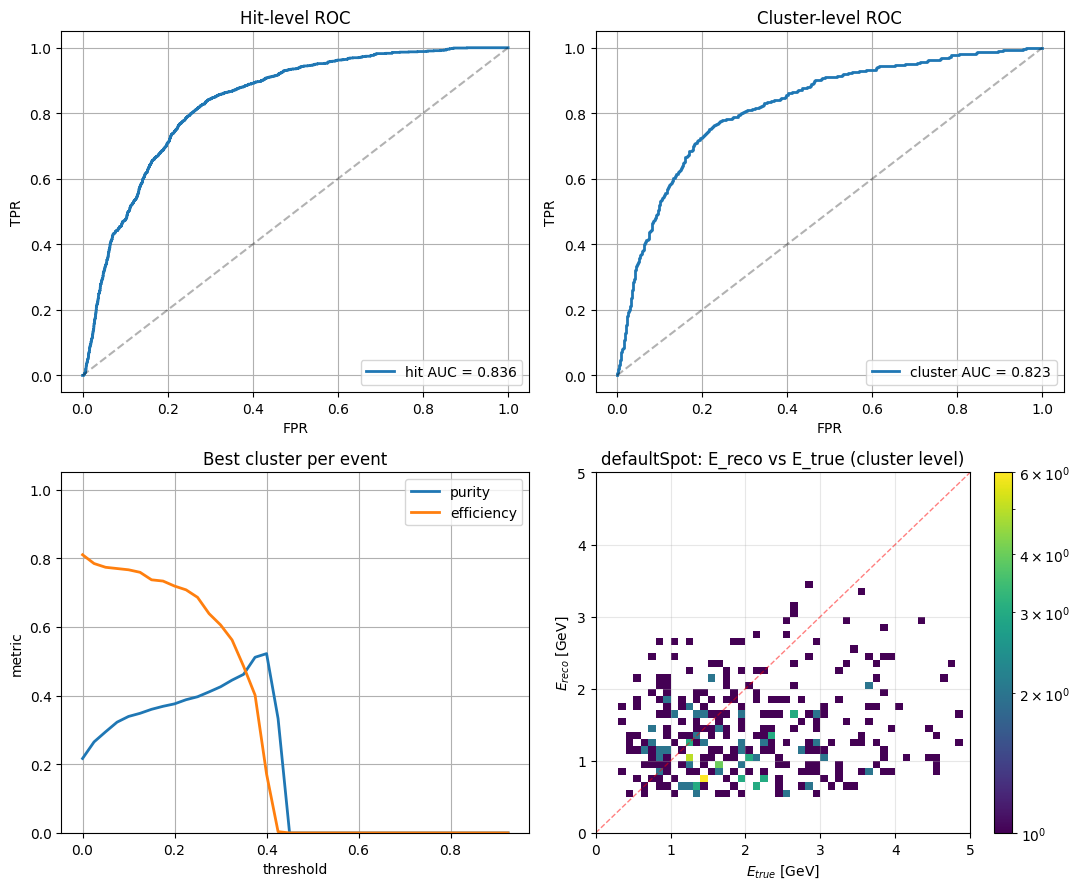

RSS after performance eval: 2.33 GB


In [10]:
from sklearn.metrics import roc_auc_score, roc_curve
from matplotlib.colors import LogNorm

perf_ds = TRAIN_DATASET
clusters = cluster_dfs[perf_ds]
# Hit-level table is next to the cluster pickle.
hits_path = os.path.join(RESULTS_DIR, f'{perf_ds}_net_default', 'pred_hits_smoke.pkl')
hits_df = pd.read_pickle(hits_path)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# (a) Hit-level ROC
ax = axes[0, 0]
if hits_df.label.nunique() > 1:
    fpr, tpr, _ = roc_curve(hits_df.label, hits_df.score)
    hit_auc = roc_auc_score(hits_df.label, hits_df.score)
    ax.plot(fpr, tpr, lw=2, label=f'hit AUC = {hit_auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('Hit-level ROC')
ax.legend(loc=4); ax.grid(True)

# (b) Cluster-level ROC (combined only — minimum details)
ax = axes[0, 1]
if clusters.cl_label.nunique() > 1:
    fpr, tpr, _ = roc_curve(clusters.cl_label, clusters.cl_score)
    cl_auc = roc_auc_score(clusters.cl_label, clusters.cl_score)
    ax.plot(fpr, tpr, lw=2, label=f'cluster AUC = {cl_auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('Cluster-level ROC')
ax.legend(loc=4); ax.grid(True)

# (c) Efficiency + purity vs threshold — best cluster per event.
ax = axes[1, 0]
best = clusters.sort_values('cl_score', ascending=False).groupby('Row').head(1).copy()
n_total_signal_events = int(clusters[clusters.cl_label == 1]['Row'].nunique())
ts = np.arange(0, 0.95, 0.025)
purs, effs = [], []
for t in ts:
    sel = best.cl_score > t
    n_sel = int(sel.sum())
    n_hit = int((sel & (best.cl_label == 1)).sum())
    purs.append(n_hit / max(n_sel, 1))
    effs.append(n_hit / max(n_total_signal_events, 1))
ax.plot(ts, purs, lw=2, label='purity')
ax.plot(ts, effs, lw=2, label='efficiency')
ax.set_ylim(0, 1.05); ax.set_xlabel('threshold'); ax.set_ylabel('metric')
ax.set_title('Best cluster per event'); ax.legend(loc=1); ax.grid(True)

# (d) E_reco vs E_true 2D — cluster level.
ax = axes[1, 1]
sel = (clusters.cl_score > 0) & (clusters.e_true > 0)
if sel.sum() > 10:
    h = ax.hist2d(clusters.loc[sel, 'e_true'], clusters.loc[sel, 'e_pred'],
                  range=[[0, 5], [0, 5]], bins=[50, 50], norm=LogNorm())
    plt.colorbar(h[3], ax=ax)
    ax.plot([0, 5], [0, 5], 'r--', lw=1, alpha=0.5)
ax.set_xlabel(r'$E_{true}$ [GeV]'); ax.set_ylabel(r'$E_{reco}$ [GeV]')
ax.set_title(f'{perf_ds}: E_reco vs E_true (cluster level)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'performance_defaultSpot.png'), dpi=130)
plt.show()
print(f'RSS after performance eval: {rss_gb():.2f} GB')


## 6. Cross-dataset sensitivity table + plot

`compare_datasets` computes `N_true_solved(Ekin)` per dataset using the
per-dataset efficiency curve (Wilson intervals) and Poisson uncertainty on
the reco yield. With only one dataset ready locally the plot degenerates
to a single curve — that's expected. The point here is to verify the
plumbing end-to-end so the cluster run's numbers are trustworthy.

In [11]:
runs = [DatasetRun(name=n, clusters_df=df) for n, df in cluster_dfs.items()]
# Match the MC-truth spectrum plot in §5b (E_RANGE=(0,6), E_BINS=40, linear):
# the default log-spaced grid stops at 3 GeV, which clips the ~3-6 GeV tail
# visible in the reference MC spectrum.
bins = np.linspace(0.0, 6.0, 41)
tables = compare_datasets(runs, bins, threshold=THRESHOLD)
print(f'sensitivity threshold: {THRESHOLD}')
print(f'Ekin bins: {len(bins)-1} linear bins over [{bins[0]:.2f}, {bins[-1]:.2f}] GeV')

# Persist for downstream analysis / for the cluster run to attach to.
for name, tab in tables.items():
    p = os.path.join(RESULTS_DIR, f'sensitivity_{name}.csv')
    tab.to_csv(p, index=False)
    print(f'  wrote {p}')

# Show the combined table so we can eyeball the numbers.
combined = tables['combined'][['dataset', 'potential_mev', 'ekin_mid',
                                'n_reco', 'epsilon', 'n_true_solved',
                                'n_true_solved_err']].copy()
combined['ekin_mid'] = combined['ekin_mid'].round(3)
combined.head(15)


sensitivity threshold: 0.35
Ekin bins: 40 linear bins over [0.00, 6.00] GeV
  wrote /Users/vovvy/Project/BM@N/HGND/HGNDRecoGNN/notebooks/results/sensitivity_smoke/sensitivity_defaultSpot.csv
  wrote /Users/vovvy/Project/BM@N/HGND/HGNDRecoGNN/notebooks/results/sensitivity_smoke/sensitivity_zeroSpot.csv
  wrote /Users/vovvy/Project/BM@N/HGND/HGNDRecoGNN/notebooks/results/sensitivity_smoke/sensitivity_bigSpot.csv
  wrote /Users/vovvy/Project/BM@N/HGND/HGNDRecoGNN/notebooks/results/sensitivity_smoke/sensitivity_combined.csv


,dataset,potential_mev,ekin_mid,n_reco,epsilon,n_true_solved,n_true_solved_err
0,defaultSpot,18.0,0.375,0,0.000000,0.000000,0.000000
1,defaultSpot,18.0,0.525,12,0.111111,108.000000,108.314542
2,defaultSpot,18.0,0.675,35,0.100000,350.000000,346.302786
3,defaultSpot,18.0,0.825,32,0.400000,80.000000,25.652483
4,defaultSpot,18.0,0.975,39,0.333333,117.000000,42.443224
5,defaultSpot,18.0,1.125,39,0.333333,117.000000,49.771980
6,defaultSpot,18.0,1.275,28,0.230769,121.333333,48.690534
7,defaultSpot,18.0,1.425,25,0.521739,47.916667,13.399325
8,defaultSpot,18.0,1.575,25,0.611111,40.909091,11.097182
9,defaultSpot,18.0,1.725,12,0.600000,20.000000,7.074136


events per dataset (from check_frames):
  defaultSpot   N_events = 1,024
  zeroSpot      N_events = 1,000
  bigSpot       N_events = 1,000


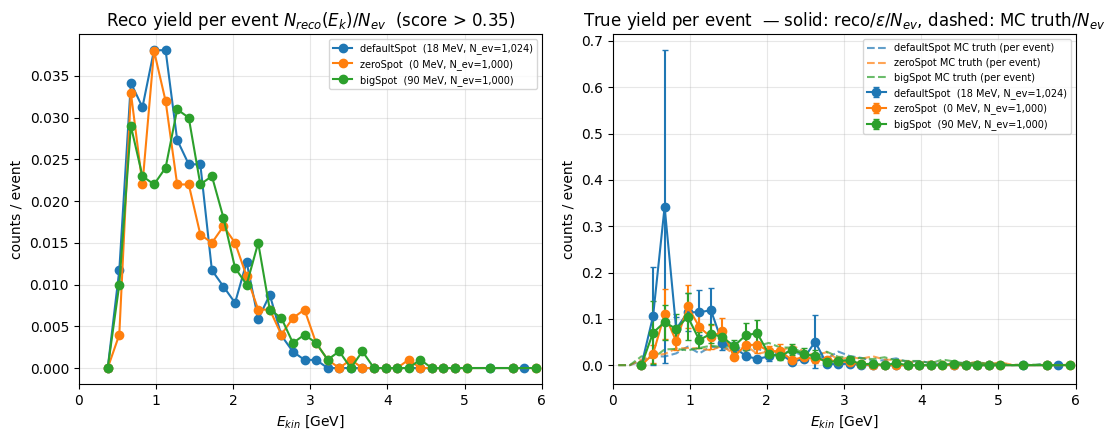

peak RSS ≈ 2.33 GB


In [12]:
# Per-event yields — divide raw counts by N_events(dataset) so datasets with
# different event counts (test-split for defaultSpot, all events for others)
# are on the same footing. MC-truth is recomputed from check_frames using the
# same recipe as §5b (one entry per unique (Row, Id) signal neutron) so the
# dashed reference line matches the MC spectrum plotted above.

def _mc_truth_per_event_from_check_frames(name, bins):
    frame = check_frames.get(name)
    if frame is None or len(frame) == 0:
        return np.zeros(len(bins) - 1), 0
    n_events = int(frame['Row'].nunique())
    mc_e = frame[frame['n0_label'] == 1].groupby(['Row', 'Id'])['Ekin'].mean()
    counts, _ = np.histogram(mc_e.to_numpy(), bins=bins)
    return counts, n_events

n_events_by_ds = {name: int(check_frames[name]['Row'].nunique())
                  for name in cluster_dfs.keys() if name in check_frames}
print('events per dataset (from check_frames):')
for n, ne in n_events_by_ds.items():
    print(f'  {n:12s}  N_events = {ne:,}')

fig, (ax_reco, ax_solved) = plt.subplots(1, 2, figsize=(11, 4.5))
for run in runs:
    tab = tables[run.name]
    n_ev = n_events_by_ds.get(run.name, 1)
    lbl = run.name + (f'  ({run.potential_mev:.0f} MeV, N_ev={n_ev:,})'
                      if run.potential_mev is not None else f'  (N_ev={n_ev:,})')
    ax_reco.plot(tab['ekin_mid'], tab['n_reco'] / n_ev, marker='o', label=lbl)
    y_solved = tab['n_true_solved'] / n_ev
    y_solved_err = tab['n_true_solved_err'] / n_ev
    ax_solved.errorbar(tab['ekin_mid'], y_solved, yerr=y_solved_err,
                       marker='o', capsize=2, label=lbl)

    # MC-truth: recompute from check_frames using the same recipe as §5b,
    # then normalize by N_events. This is the "correct" reference — the
    # cluster-level cl_label counts from compare_datasets are what the reco
    # sees, not the ground-truth neutron count per event.
    mc_counts, mc_nev = _mc_truth_per_event_from_check_frames(run.name, bins)
    mc_mid = 0.5 * (bins[:-1] + bins[1:])
    mc_per_ev = mc_counts / max(mc_nev, 1)
    ax_solved.plot(mc_mid, mc_per_ev, ls='--', alpha=0.7,
                   color=ax_solved.lines[-1].get_color(),
                   label=f'{run.name} MC truth (per event)')

for ax, ttl in ((ax_reco,   r'Reco yield per event $N_{reco}(E_k)/N_{ev}$  (score > ' + f'{THRESHOLD})'),
                (ax_solved, r'True yield per event  — solid: reco/$\varepsilon$/$N_{ev}$, dashed: MC truth/$N_{ev}$')):
    ax.set_xlim(0, 6); ax.set_xlabel(r'$E_{kin}$ [GeV]')
    ax.grid(True, which='both', alpha=0.3); ax.set_title(ttl); ax.legend(fontsize=7)
ax_reco.set_ylabel('counts / event'); ax_solved.set_ylabel('counts / event')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sensitivity_smoke.png'), dpi=120)
plt.show()
print(f'peak RSS ≈ {rss_gb():.2f} GB')


## 7. Handoff

- The prediction pickles under `results/sensitivity_smoke/*/pred_clusters_smoke.pkl`
  are drop-in inputs for `scripts/sensitivity.py`.
- The cluster smoke reproduction is `slurm/sensitivity_smoke.sbatch`; it
  runs the same three CLIs (`train.py`, `evaluate.py`, `sensitivity.py`).
- For the full run (all events, 20 epochs, hidden=512, all 3 datasets),
  submit `slurm/sensitivity_full.sbatch --array=0-2` and open
  `notebooks/sensitivity_full_analysis.ipynb` to inspect the output.

If a cell above raised on this laptop, the recovery is: (a) reduce
`NUM_SHARDS` to 1 or `BATCH_SIZE` to 16, (b) rerun. If it still crashes,
the problem is upstream — check `HGNDRecoGNN.device.available_memory_gb()`
and close other apps.